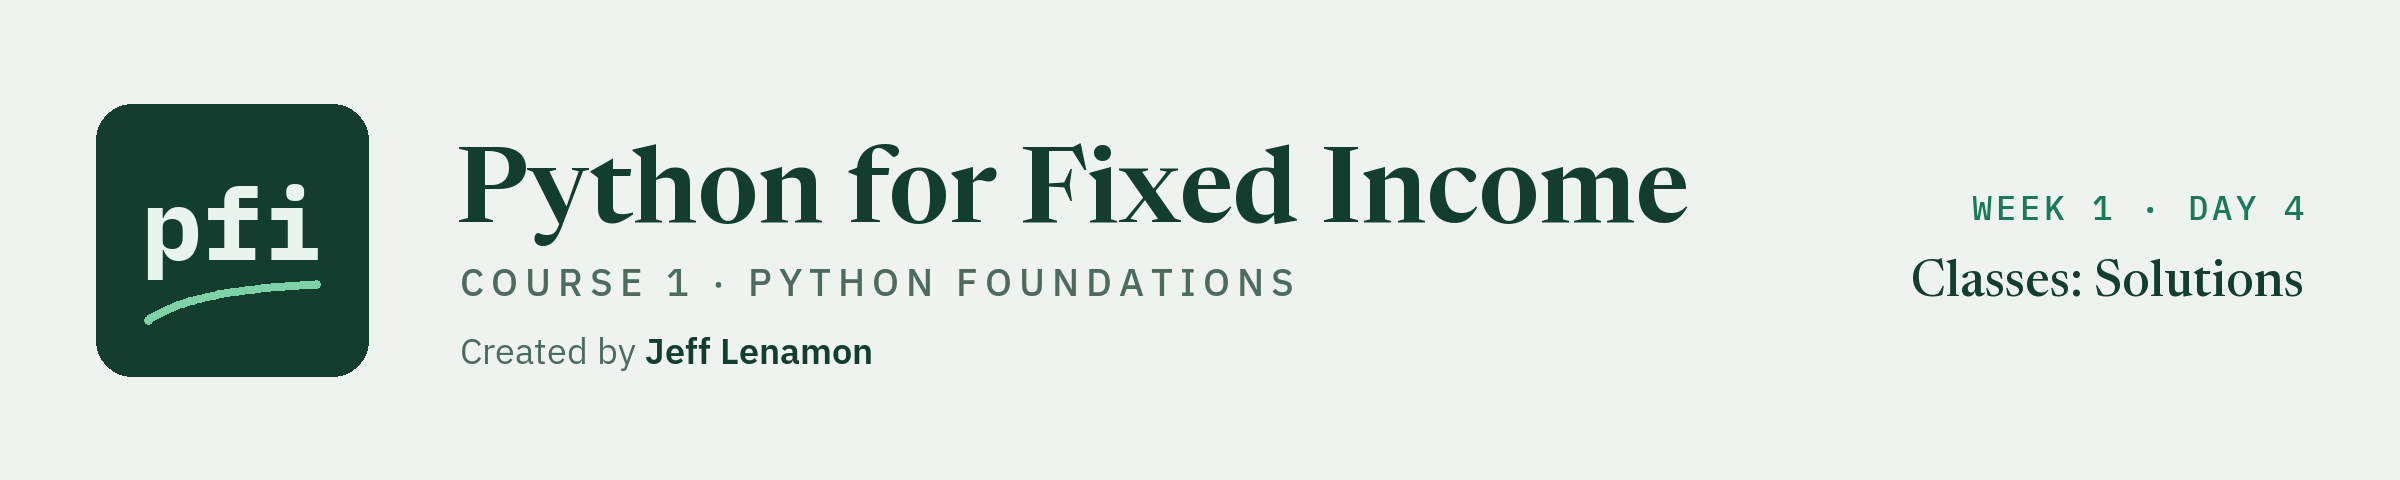

# Classes: A Bond Object - Solutions

Week 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day4/04_classes_a_bond_object_solutions.ipynb)

## Exercises

A second desk holds three positions. The issuers are invented.

| Ticker | Face held | Price |
| --- | --- | --- |
| TRNW | 2,000,000 | 96.25 |
| OSMC | 1,250,000 | 100.00 |
| CLDB | 500,000 | 104.50 |

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check`, which marks your answers.

In [1]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)

### Exercise 1

Q. Complete the class **Position** below. The initializer should store the ticker, face, and price. The method `market_value()` should return face times price divided by 100. Then the code creates the TRNW position and stores its market value in **ex1_market_value**.

In [2]:
class Position:
    def __init__(self, ticker, face, price):
        # store each value on the object
        self.ticker = ticker
        self.face = face
        self.price = price

    def market_value(self):
        # the price is per 100 face, so divide by 100
        return self.face * self.price / 100


trnw = Position('TRNW', 2000000, 96.25)
ex1_market_value = trnw.market_value()
print('TRNW market value:', ex1_market_value)

TRNW market value: 1925000.0


In [3]:
check('Exercise 1', ex1_market_value, 1925000.0)

Exercise 1: correct


### Exercise 2

Q. Write the class again and add a method `is_premium()` that returns True when the price is above 100 and False otherwise. Then create all three positions. The code stores whether CLDB is at a premium in **ex2_cldb_premium** and whether OSMC is in **ex2_osmc_premium**.

In [4]:
class Position:
    def __init__(self, ticker, face, price):
        self.ticker = ticker
        self.face = face
        self.price = price

    def market_value(self):
        return self.face * self.price / 100

    def is_premium(self):
        # a comparison is already True or False, so it can be returned directly
        return self.price > 100


trnw = Position('TRNW', 2000000, 96.25)
osmc = Position('OSMC', 1250000, 100.0)
cldb = Position('CLDB', 500000, 104.5)

ex2_cldb_premium = cldb.is_premium()
ex2_osmc_premium = osmc.is_premium()
print('CLDB at a premium:', ex2_cldb_premium)
print('OSMC at a premium:', ex2_osmc_premium)

CLDB at a premium: True
OSMC at a premium: False


* OSMC is priced at exactly 100. That is par, not a premium, so the test `price > 100` correctly returns False.

In [5]:
check('Exercise 2 CLDB', ex2_cldb_premium, True)
check('Exercise 2 OSMC', ex2_osmc_premium, False)

Exercise 2 CLDB: correct
Exercise 2 OSMC: correct


### Exercise 3

Q. Put the three positions in a list and use a loop to find the total market value. Store it in **ex3_total_value**.

In [6]:
# a list of Position objects
positions = [trnw, osmc, cldb]

# start a running total at zero
ex3_total_value = 0
for position in positions:
    ex3_total_value = ex3_total_value + position.market_value()

print('Total market value:', ex3_total_value)

Total market value: 3697500.0


In [7]:
check('Exercise 3', ex3_total_value, 3697500.0)

Exercise 3: correct


### Exercise 4

Q. The desk sells 500,000 face of TRNW, leaving 1,500,000. Update the face on the TRNW object, then store its new market value in **ex4_market_value**.

In [8]:
# change the attribute on the object
trnw.face = 1500000
# the method works the market value out again from the new face
ex4_market_value = trnw.market_value()
print('TRNW market value:', ex4_market_value)

TRNW market value: 1443750.0


* Nothing else had to change. Because `market_value()` calculates from the attributes each time, it picked up the new face on its own.

In [9]:
check('Exercise 4', ex4_market_value, 1443750.0)

Exercise 4: correct


### Exercise 5

Q. Write the class once more and add a `__str__` method, so that printing a position shows its ticker, its face with thousands separators, and its price to 2 decimals, in this form: `CLDB 500,000 at 104.50`. Build the text with an f-string. Then store `str(cldb)` in **ex5_text**. `str()` gives the same text that `print()` shows.

In [10]:
class Position:
    def __init__(self, ticker, face, price):
        self.ticker = ticker
        self.face = face
        self.price = price

    def market_value(self):
        return self.face * self.price / 100

    def __str__(self):
        # the comma adds thousands separators to the face, and .2f shows the price to 2 decimals
        return f'{self.ticker} {self.face:,} at {self.price:.2f}'


cldb = Position('CLDB', 500000, 104.5)
# print() calls __str__ for us
print(cldb)
# str() calls it too, and hands the text back so it can be stored
ex5_text = str(cldb)

CLDB 500,000 at 104.50


* `__str__` returns the text and prints nothing itself. `print(cldb)` and `str(cldb)` both call it, so the two always agree.
* The format codes are the ones from day 1: `:,` for the face and `:.2f` for the price, which keeps the trailing zero of 104.50.

In [11]:
check('Exercise 5', ex5_text, 'CLDB 500,000 at 104.50')

Exercise 5: correct


### Exercise 6: AI check

You ask an AI assistant for a position class with a method that marks the position to a new price. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

The code creates a position of 2,000,000 face at a price of 96.25, marks it to 97.00, and prints the market value.

Q. Before you run it, work out what the market value should be after the mark. Then run the code. Does it agree with you?

* After the mark the market value should be 2,000,000 times 97.00 divided by 100, which is 1,940,000. The original code printed 1,925,000, the market value at the old price, with no error.
* The bug was in `mark()`. It said `price = new_price`, which creates a throwaway variable inside the method and then forgets it. To change the object, the line has to be `self.price = new_price`.
* A missing `self.` is easy to overlook because the code still runs. The check that caught it was working out the expected answer first.

In [12]:
class MarkedPosition:
    def __init__(self, ticker, face, price):
        self.ticker = ticker
        self.face = face
        self.price = price

    def market_value(self):
        return self.face * self.price / 100

    def mark(self, new_price):
        # self.price changes the attribute on the object
        self.price = new_price


marked = MarkedPosition('TRNW', 2000000, 96.25)
marked.mark(97.0)
ex6_value_after_mark = marked.market_value()
print(f'Market value after the mark: {ex6_value_after_mark:,.2f}')

Market value after the mark: 1,940,000.00


In [13]:
check('Exercise 6', ex6_value_after_mark, 1940000.0)

Exercise 6: correct
